# **Principal Component Analysis (PCA)**

### **Import Libraries**

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### **Load Dataset**

In [70]:
iris = load_iris()

X = pd.DataFrame(data=iris.data, columns=iris.feature_names)
y = iris.target

df = X.copy()
df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### **EDA (Pairplot)**

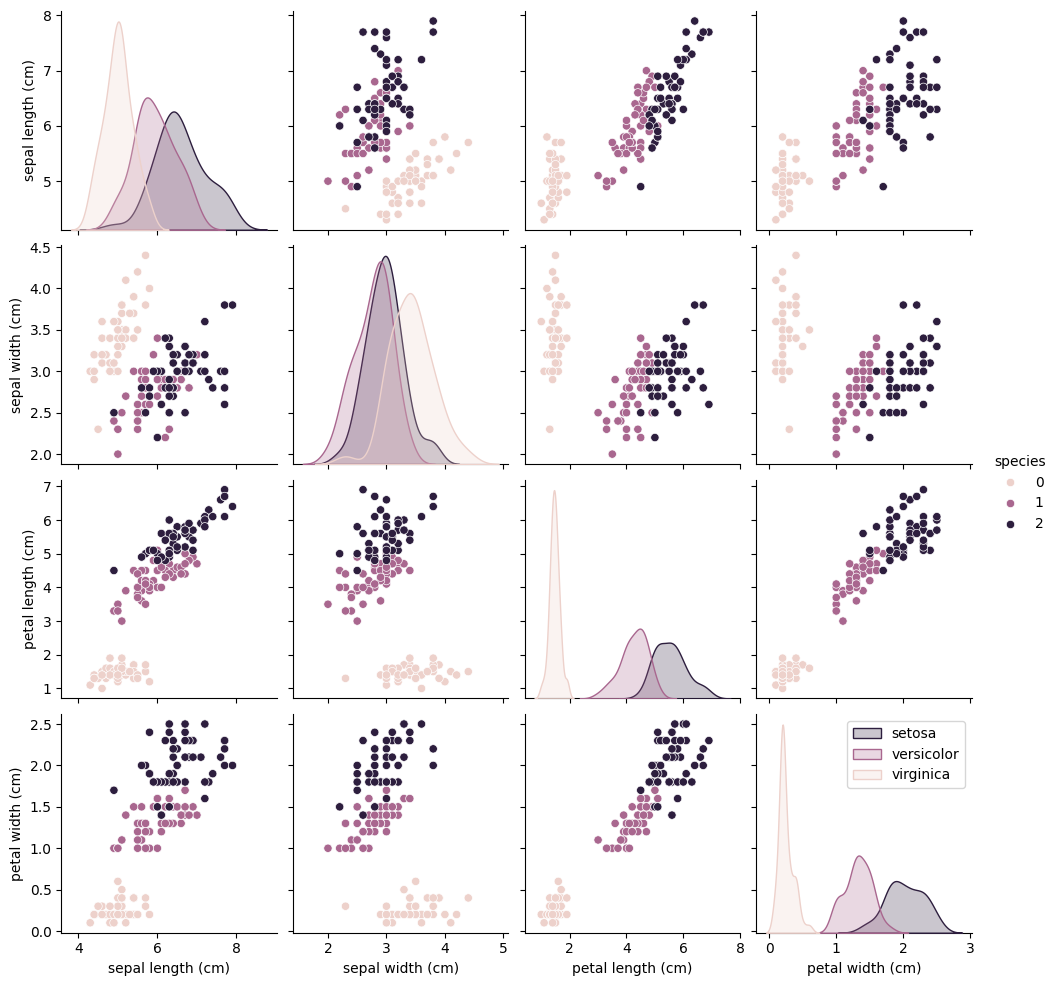

In [71]:
sns.pairplot(data=df, hue="species")
plt.legend(labels=iris.target_names)
plt.show()

### **Feature Scaling**

In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Apply PCA**

In [73]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### **Explained Variance**

In [74]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.72962445 0.22850762]


### **Convert to DataFrame**

In [75]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

pca_df.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


### **Visualization(2D PCA plot)**

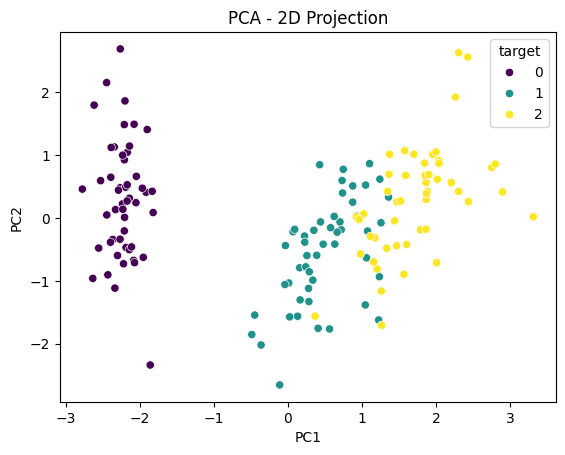

In [76]:
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='target',
    palette='viridis',
    data=pca_df
)

plt.title("PCA - 2D Projection")
plt.show()

### **Variance Plot**

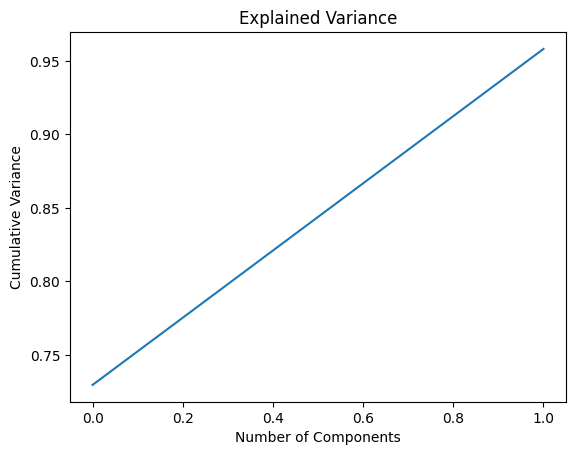

In [77]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Explained Variance")
plt.show()

### **Conclusion:**

PCA successfully reduced the dataset to two principal components while retaining approximately **95.8% of the total variance**. The 2D projection clearly shows well-separated clusters for different classes, indicating that most of the important information is preserved. This demonstrates that PCA is effective for dimensionality reduction and visualization without significant loss of information.